# Numpy Autograd Demo

In this notebook, we will demonstrate our from-scratch implementation of basic machine learning framework functionality using only Python and NumPy.

## Imports

In [28]:
import os

from autograd import Tensor, cross_entropy_loss
from optimizers import SGD
from modules import FFN
from utils import Dataset, DataLoader
from datasets import load_dataset
import numpy as np

import matplotlib.pyplot as plt

## Config

In [29]:
DATA_REPO = "ylecun/mnist"
LR = 0.0001
MOMENTUM = 0.9
EPOCHS = 5
BATCH_SIZE = 32

## Data

In [30]:
class MNISTDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        return Tensor(
            np.array(item["image"], dtype=np.float32).flatten() / 255.0,
            requires_grad=False,
        ), Tensor(np.array([item["label"]], dtype=np.int64), requires_grad=False)

In [31]:
from datasets import Value, Sequence

data = load_dataset("ylecun/mnist")
train_data = MNISTDataset(data["train"])
test_data = MNISTDataset(data["test"])
train_data, test_data

(<__main__.MNISTDataset at 0x2119b1712b0>,
 <__main__.MNISTDataset at 0x211a06274d0>)

In [32]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## Training

In [33]:
model = FFN(in_features=28 * 28, hidden_features=128, out_features=10)
loss_values = []
optimizer = SGD(model.parameters, lr=LR, momentum=MOMENTUM)
criterion = cross_entropy_loss

for epoch in range(EPOCHS):
    total_loss = 0.0
    for batch_idx, (images, labels) in enumerate(train_loader):

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        total_loss += loss.data

        loss.backward()
        loss_values.append(loss.data.item())

        optimizer.step()

        if (batch_idx + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{EPOCHS}], Step {batch_idx+1}, Loss: {total_loss / (batch_idx + 1):.4f}"
            )

    print(f"Epoch [{epoch+1}/{EPOCHS}] completed.")

Epoch [1/5], Step 100, Loss: 2.4041
Epoch [1/5], Step 200, Loss: 2.3464
Epoch [1/5], Step 300, Loss: 2.2915
Epoch [1/5], Step 400, Loss: 2.2452
Epoch [1/5], Step 500, Loss: 2.2042
Epoch [1/5], Step 600, Loss: 2.1645
Epoch [1/5], Step 700, Loss: 2.1287
Epoch [1/5], Step 800, Loss: 2.0913
Epoch [1/5], Step 900, Loss: 2.0577
Epoch [1/5], Step 1000, Loss: 2.0239
Epoch [1/5], Step 1100, Loss: 1.9889
Epoch [1/5], Step 1200, Loss: 1.9561
Epoch [1/5], Step 1300, Loss: 1.9223
Epoch [1/5], Step 1400, Loss: 1.8896
Epoch [1/5], Step 1500, Loss: 1.8572
Epoch [1/5], Step 1600, Loss: 1.8259
Epoch [1/5], Step 1700, Loss: 1.7948
Epoch [1/5], Step 1800, Loss: 1.7646
Epoch [1/5] completed.
Epoch [2/5], Step 100, Loss: 1.1601
Epoch [2/5], Step 200, Loss: 1.1437
Epoch [2/5], Step 300, Loss: 1.1131
Epoch [2/5], Step 400, Loss: 1.0975
Epoch [2/5], Step 500, Loss: 1.0790
Epoch [2/5], Step 600, Loss: 1.0658
Epoch [2/5], Step 700, Loss: 1.0502
Epoch [2/5], Step 800, Loss: 1.0364
Epoch [2/5], Step 900, Loss: 1.0

## Evaluation

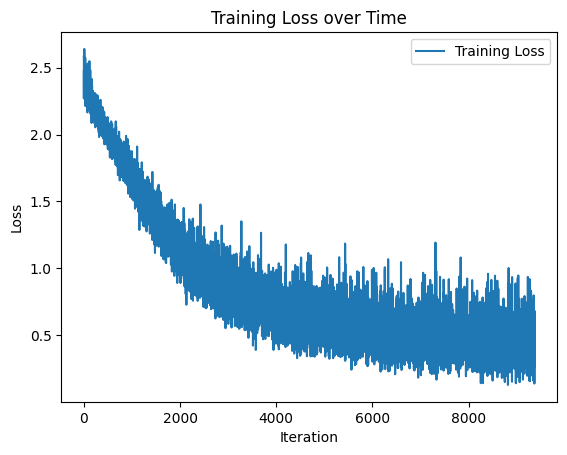

In [34]:
plt.plot(loss_values, label="Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Time")
plt.legend()
plt.show()

In [35]:
correct_example_images, correct_example_labels = [], []
incorrect_example_images, incorrect_example_labels, incorrect_predictions = [], [], []

test_loader = DataLoader(test_data, batch_size=5, shuffle=False)

correct = 0
total = 0

for images, labels in test_loader:
    outputs = model(images)
    predicted = np.argmax(outputs.data, axis=1)
    total += labels.shape[0]
    correct += (predicted == labels.data.flatten()).sum().item()

    if len(correct_example_images) < 5 or len(incorrect_example_images) < 5:
        for img, lbl, pred in zip(images.data, labels.data.flatten(), predicted):
            if lbl == pred:
                if len(correct_example_images) < 5:
                    correct_example_images.append(img.reshape(28, 28))
                    correct_example_labels.append(lbl)
            elif lbl != pred:
                if len(incorrect_example_images) < 5:
                    incorrect_example_images.append(img.reshape(28, 28))
                    incorrect_example_labels.append(lbl)
                    incorrect_predictions.append(pred)

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 88.5%


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)] [np.int64(5), np.int64(6), np.int64(4), np.int64(2), np.int64(6)]
5 5


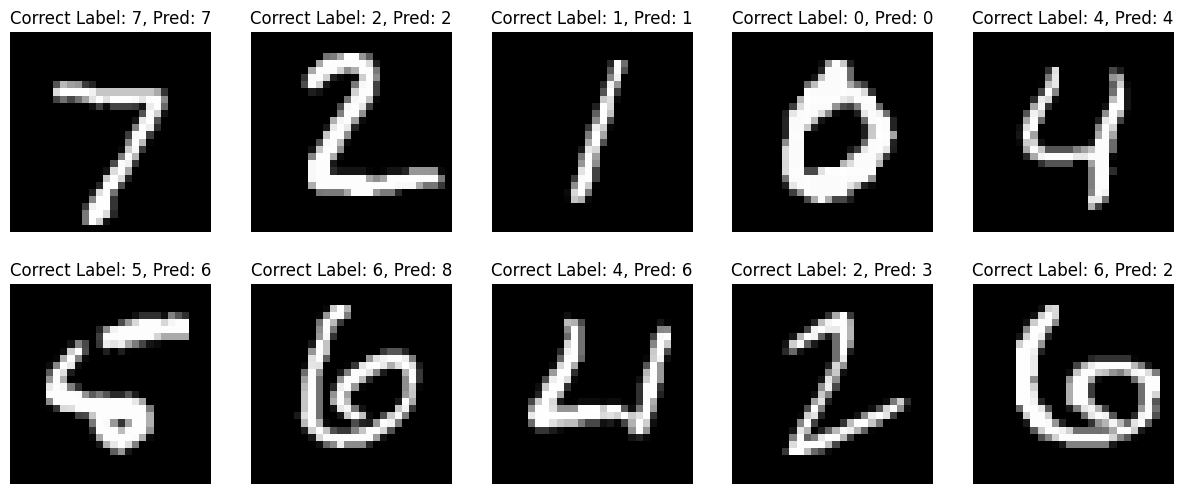

In [37]:
print(correct_example_labels, incorrect_example_labels)
print(len(correct_example_images), len(incorrect_example_images))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(correct_example_images[i], cmap="gray")
    axes[0, i].set_title(f"Correct Label: {correct_example_labels[i]}, Pred: {correct_example_labels[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(incorrect_example_images[i], cmap="gray")
    axes[1, i].set_title(
        f"Correct Label: {incorrect_example_labels[i]}, Pred: {incorrect_predictions[i]}"
    )
    axes[1, i].axis("off")
plt.show()